# Hispanic-Black Valence Across Layers — GPT-2

**Phase 4:** Layer-by-layer valence analysis of the Hispanic-Black encoding direction.

Produces Figure 8 from the paper.

**Hardware:** M4 Mac Mini or any GPU  
**Runtime:** ~3 minutes  
**Run all cells top to bottom.**

**Output:** `valence_layer_by_layer.png`


In [7]:
# Configuration — set path to your white_encoding_results.pkl
PKL_PATH = '/content/drive/MyDrive/ID-UTH-repo/results/white_encoding_results.pkl'
OUTPUT_DIR = '/content/drive/MyDrive/ID-UTH-repo/results/valence'
TARGET_LAYERS = [3, 6, 9, 11]
TOP_K = 10

import os
from google.colab import drive
try:
    drive.mount('/content/drive')
except ValueError:
    pass
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Config ready.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Config ready.


In [8]:
!pip install -q numpy==1.26.4
!pip install -q transformer_lens

import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
from transformer_lens import HookedTransformer
print('Ready.')


Ready.


In [9]:
# Load activations — White-Black direction
with open(PKL_PATH, 'rb') as f:
    raw = pickle.load(f)

group_records = raw['group_records']
print('Groups:', list(group_records.keys()))

layer_activations = {}
for layer in TARGET_LAYERS:
    key = f'layer_{layer}'
    w_acts = np.array([r[key] for r in group_records['White']])
    b_acts = np.array([r[key] for r in group_records['Black']])
    layer_activations[layer] = {'white': w_acts, 'black': b_acts}
    print(f'Layer {layer}: White {w_acts.shape}, Black {b_acts.shape}')


Groups: ['White', 'Black', 'Hispanic']
Layer 3: White (48, 768), Black (48, 768)
Layer 6: White (48, 768), Black (48, 768)
Layer 9: White (48, 768), Black (48, 768)
Layer 11: White (48, 768), Black (48, 768)


In [10]:
# Load GPT-2 embedding matrix for vocab projection
print('Loading GPT-2...')
DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
gpt2 = HookedTransformer.from_pretrained('gpt2', device=DEVICE)
gpt2.eval()

W_E = gpt2.embed.W_E.detach().cpu().numpy()  # (50257, 768)
tokenizer = gpt2.tokenizer
vocab = [tokenizer.decode([i]).strip() for i in range(W_E.shape[0])]
print(f'W_E shape: {W_E.shape}, vocab size: {len(vocab)}')

del gpt2
if torch.cuda.is_available(): torch.cuda.empty_cache()
print('Model freed.')


Loading GPT-2...
Loaded pretrained model gpt2 into HookedTransformer
W_E shape: (50257, 768), vocab size: 50257
Model freed.


In [11]:
# Difference-of-means + vocab projection (White - Black direction)
def dom_direction(acts_a, acts_b):
    direction = acts_a.mean(axis=0) - acts_b.mean(axis=0)
    return direction / (np.linalg.norm(direction) + 1e-8)

def project_vocab(direction, W_E, vocab, top_k=TOP_K):
    norms = np.linalg.norm(W_E, axis=1, keepdims=True) + 1e-8
    scores = (W_E / norms) @ direction
    top_idx = np.argsort(scores)[::-1][:top_k]
    bot_idx = np.argsort(scores)[:top_k]
    return [(vocab[i], float(scores[i])) for i in top_idx], \
           [(vocab[i], float(scores[i])) for i in bot_idx]

layer_results = {}
for layer in TARGET_LAYERS:
    w = layer_activations[layer]['white']
    b = layer_activations[layer]['black']
    direction = dom_direction(w, b)
    top, bot = project_vocab(direction, W_E, vocab)
    layer_results[layer] = {'top': top, 'bottom': bot}
    print(f'Layer {layer}:')
    print(f'  White pole: {[t for t,s in top[:5]]}')
    print(f'  Black pole: {[t for t,s in bot[:5]]}')


Layer 3:
  White pole: ['rotein', 'aukee', 'ghai', 'Poo', 'ween']
  Black pole: ['black', 'suit', 'Internet', 's', 'Comp']
Layer 6:
  White pole: ['aukee', 'bilt', 'State', 'insula', 'ablishment']
  Black pole: ['any', 'strap', 'smith', 'ened', 'trace']
Layer 9:
  White pole: ['bilt', 'ographically', 'ocol', 'ghai', 'insula']
  Black pole: ['smith', 'tie', 'tr', 'ened', 'black']
Layer 11:
  White pole: ['House', '.', 'post', '(', ',']
  Black pole: ['feet', 'rahim', 'Lives', 'protester', 'smith']


Saved: /content/drive/MyDrive/ID-UTH-repo/results/valence/white_black_valence_by_layer.png


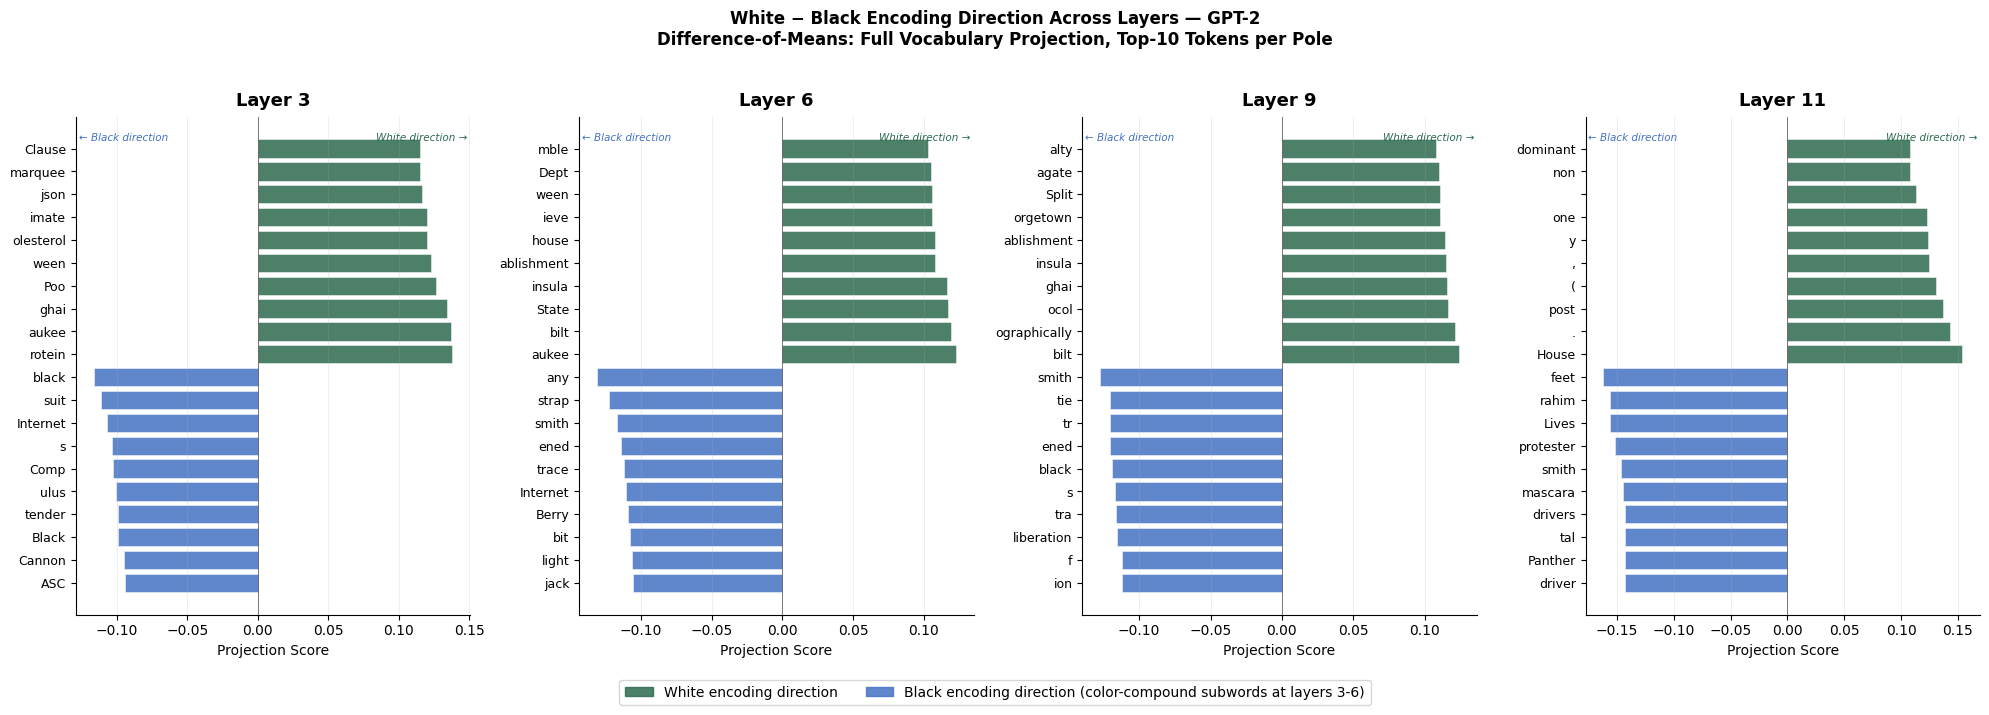

In [12]:
# Figure 8 — White-Black valence across all layers
WHITE_COLOR = '#2D6A4F'
BLACK_COLOR = '#4472C4'

fig, axes = plt.subplots(1, 4, figsize=(20, 6.5), sharey=False)

for ax, layer in zip(axes, TARGET_LAYERS):
    top = layer_results[layer]['top']
    bot = layer_results[layer]['bottom']
    all_items = list(reversed(bot)) + list(top)
    labels = [t for t, s in all_items]
    scores = [s for t, s in all_items]
    colors = [BLACK_COLOR if s < 0 else WHITE_COLOR for s in scores]

    y_pos = range(len(all_items))
    ax.barh(y_pos, scores, color=colors, alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.7, alpha=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Projection Score', fontsize=10)
    ax.set_title(f'Layer {layer}', fontsize=13, fontweight='bold', pad=8)
    ax.grid(axis='x', alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    xlim = ax.get_xlim()
    ax.text(xlim[0]+0.002, len(all_items)-0.3,
            '← Black direction', fontsize=7.5,
            color=BLACK_COLOR, va='top', style='italic')
    ax.text(xlim[1]-0.002, len(all_items)-0.3,
            'White direction →', fontsize=7.5,
            color=WHITE_COLOR, va='top', ha='right', style='italic')

w_patch = mpatches.Patch(color=WHITE_COLOR, alpha=0.85, label='White encoding direction')
b_patch = mpatches.Patch(color=BLACK_COLOR, alpha=0.85, label='Black encoding direction (color-compound subwords at layers 3-6)')
fig.legend(handles=[w_patch, b_patch], loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.06))
fig.suptitle(
    'White − Black Encoding Direction Across Layers — GPT-2\n'
    'Difference-of-Means: Full Vocabulary Projection, Top-10 Tokens per Pole',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
out = f'{OUTPUT_DIR}/white_black_valence_by_layer.png'
plt.savefig(out, dpi=300, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()
